# Notebook 3: How Experimental Probabilities Arise

In this notebook, we bridge the gap between abstract quantum amplitudes and laboratory histograms. We will:
1. Define a single-qubit state with analytically known probabilities.
2. Sample outcomes over multiple shot counts (100, 1000, 10000).
3. Introduce readout flip noise to simulate experimental error.
4. Compare ideal theory, ideal sampling, and noisy sampling in a table and plot.

## Section 1: Exact Probabilities from Statevector

Let's prepare the state $|\psi\rangle = RY(\theta)|0\rangle$ with $\theta = \pi/3$.
The exact state is:
$$|\psi\rangle = \cos\frac{\pi}{6}|0\rangle + \sin\frac{\pi}{6}|1\rangle = \frac{\sqrt{3}}{2}|0\rangle + \frac{1}{2}|1\rangle$$
This gives the exact probabilities:
$$P(0) = 0.75, \qquad P(1) = 0.25$$

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

theta = np.pi / 3
qc = QuantumCircuit(1)
qc.ry(theta, 0)

sv = Statevector.from_instruction(qc)
exact_probs = sv.probabilities()
print(f"Exact ideal probabilities: P(0) = {exact_probs[0]:.4f}, P(1) = {exact_probs[1]:.4f}")

Exact ideal probabilities: P(0) = 0.7500, P(1) = 0.2500


## Section 2: Finite-Shot Sampling

A real quantum computer runs the circuit $N$ times (shots) and counts the frequency of each outcome. We will simulate this for different shot sizes.

In [2]:
import pandas as pd
from qiskit_aer import AerSimulator

qc_meas = qc.copy()
qc_meas.measure_all()
sim = AerSimulator()

data = []
shot_counts = [100, 1000, 10000]

for shots in shot_counts:
    result = sim.run(qc_meas, shots=shots).result()
    counts = result.get_counts()
    p0_est = counts.get('0', 0) / shots
    p1_est = counts.get('1', 0) / shots
    data.append({"Shots": shots, "Sampled P(0)": p0_est, "Sampled P(1)": p1_est})

df_sampled = pd.DataFrame(data)
print("Convergence of sampled frequencies:")
print(df_sampled.to_string(index=False))

Convergence of sampled frequencies:
 Shots  Sampled P(0)  Sampled P(1)
   100        0.7100        0.2900
  1000        0.7500        0.2500
 10000        0.7451        0.2549


## Section 3: Readout Noise Simulation

In real hardware, sometimes a state prepared as $0$ is misread as $1$ (and vice versa) due to measurement errors. We model this as a classical readout flip with probability $p_{\text{flip}} = 0.1$.

In [3]:
p_flip = 0.1
shots = 10000

# Run the ideal simulation for 10000 shots
counts_ideal = sim.run(qc_meas, shots=shots).result().get_counts()

# Simulate readout flip error
counts_noisy = {'0': 0, '1': 0}
for bit_string, count in counts_ideal.items():
    for _ in range(count):
        if np.random.rand() < p_flip:
            # Flip the bit string
            flipped_string = '1' if bit_string == '0' else '0'
            counts_noisy[flipped_string] += 1
        else:
            counts_noisy[bit_string] += 1

print(f"Ideal counts (10k shots): {counts_ideal}")
print(f"Noisy counts (10k shots with 10% flip error): {counts_noisy}")

Ideal counts (10k shots): {'0': 7604, '1': 2396}
Noisy counts (10k shots with 10% flip error): {'0': 7028, '1': 2972}


## Section 4: Visualizing Theory vs. Simulation vs. Noise

Let's combine these results into a comparison dataframe and plot a bar chart.

Basis State  Ideal Theory  Sampled (Ideal 10k shots)  Sampled (Noisy 10k shots)
        |0>          0.75                     0.7604                     0.7028
        |1>          0.25                     0.2396                     0.2972


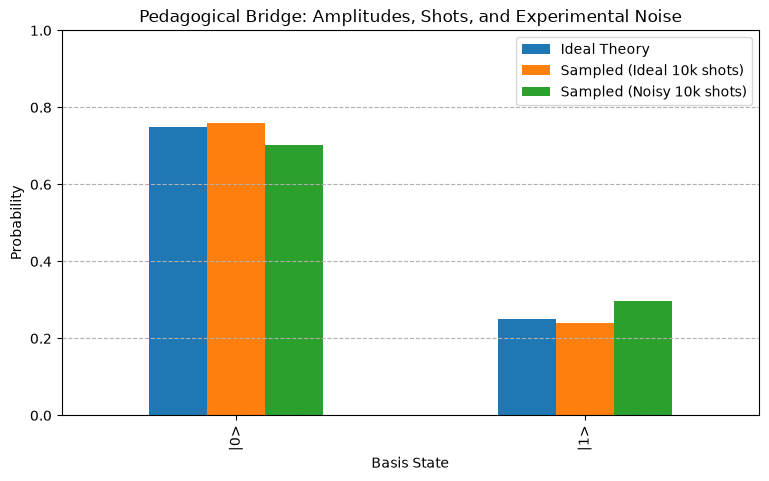

In [4]:
import matplotlib.pyplot as plt

# Compile the final comparison summary
comparison = {
    "Basis State": ["|0>", "|1>"],
    "Ideal Theory": [exact_probs[0], exact_probs[1]],
    "Sampled (Ideal 10k shots)": [counts_ideal.get('0', 0) / shots, counts_ideal.get('1', 0) / shots],
    "Sampled (Noisy 10k shots)": [counts_noisy.get('0', 0) / shots, counts_noisy.get('1', 0) / shots]
}

df_compare = pd.DataFrame(comparison)
print(df_compare.to_string(index=False))

# Plot comparison chart
df_compare.set_index("Basis State").plot(kind="bar", figsize=(9, 5))
plt.title("Pedagogical Bridge: Amplitudes, Shots, and Experimental Noise")
plt.ylabel("Probability")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()